In [16]:
try:
    from google.colab import drive

    drive.mount('/content/drive', force_remount=False)

    print("Google Drive is mounted correctly")

except ModuleNotFoundError:

    print("Local environment detected (not Colab)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive is mounted correctly


In [17]:
##########################################################################
# IMPORTS
##########################################################################

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress, t


In [18]:
##########################################################################
# GENERAL SETTINGS
##########################################################################

class ConfiguracionExperimento:
    def __init__(self):

        # File path
        self.ruta_archivos = (
            "/content/drive/MyDrive/Doctorado/Proyecto_ICF/reduccion colorante con aunps papalo 24 01 2025-20260513T215036Z-3-001/"
        )

        # File
        self.archivos = [
            f"REDU COL. Ver +  H2O + NaBH4 + AuNPs PAPALO  {i}.TXT"
            for i in range(1, 5)
        ]

        self.archivos = [
            self.ruta_archivos + f
            for f in self.archivos
        ]

        # Experimental parameters
        self.m = 0.000000985
        self.M = 0.00065

        self.masa_molar_catalizador = 196.97
        self.masa_molar_contaminante = 663.575

        self.T = 298.15

        # Physical constants
        self.kb = 1.380649e-23
        self.h = 6.62607015e-34
        self.R = 8.314

        # Data for graphs
        self.valores_primera = [422]
        self.valores_ultima = [245, 260, 285]

        self.lambda_objetivo = 410

In [19]:
##########################################################################
# DATA READING AND PROCESSING
##########################################################################

class LectorUVVis:

    @staticmethod
    def extraer_datos(nombre_archivo):

        with open(nombre_archivo, 'r', encoding='latin1') as f:
            lineas = f.readlines()

        inicio = None

        for i, linea in enumerate(lineas):

            if "Data Points" in linea:
                inicio = i + 2
                break

        if inicio is None:
            raise ValueError(
                f"No ‘Data Points’ were found in {nombre_archivo}"
            )

        df = pd.read_csv(
            nombre_archivo,
            sep="\t",
            skiprows=inicio,
            names=["nm", "Abs"],
            encoding='latin1'
        )


        df = df.dropna()


        df["nm"] = pd.to_numeric(df["nm"], errors="coerce")
        df["Abs"] = pd.to_numeric(df["Abs"], errors="coerce")


        df = df.dropna()

        return df


    @staticmethod
    def verificar_archivos(lista_archivos):

        archivos_limpios = []

        for archivo in lista_archivos:


            if not os.path.exists(archivo):

                print(f"⚠️ File not found: {archivo}")

            else:


                archivos_limpios.append(archivo)


                df = LectorUVVis.extraer_datos(archivo)


                nombre_salida = (
                    os.path.splitext(
                        os.path.basename(archivo)
                    )[0]
                    + "_limpio.txt"
                )

                # Save as a plain text file
                df.to_csv(
                    config.ruta_archivos + nombre_salida,
                    sep="\t",
                    index=False
                )

        return archivos_limpios


##########################################################################
# EXECUTION
##########################################################################

config = ConfiguracionExperimento()

archivos_validos = LectorUVVis.verificar_archivos(
    config.archivos
)

In [20]:
##########################################################################
# STYLE SETTINGS
##########################################################################

class EstiloGraficas:

    @staticmethod
    def aplicar_estilo():

        plt.rcParams.update({
            "font.size": 14,
            "axes.labelsize": 14,
            "axes.titlesize": 14,
            "legend.fontsize": 12,
            "xtick.labelsize": 12,
            "ytick.labelsize": 12,
            "axes.linewidth": 1.5,
            "lines.linewidth": 2,
            "xtick.direction": "in",
            "ytick.direction": "in",
            "axes.labelweight": "bold",
            "axes.titleweight": "bold"
        })


In [21]:
##########################################################################
# UV-VIS PLOTTER
##########################################################################

class GraficaUVVis:

    def __init__(self, config):

        self.config = config
        self.y_primera = {}
        self.y_ultima = {}

    def graficar_espectros(self):

        plt.figure(figsize=(10, 6))

        EstiloGraficas.aplicar_estilo()

        for i, archivo in enumerate(self.config.archivos):

            df = LectorUVVis.extraer_datos(archivo)

            self._graficar_curva(df, i)
            self._guardar_lineas_referencia(df, i)

        self._dibujar_lineas_verticales()
        self._dibujar_flechas()
        self._configurar_ejes()
        self._guardar_figura()

        plt.show()

    def _graficar_curva(self, df, indice):

        plt.plot(
            df["nm"],
            df["Abs"],
            label=rf"$\mathrm{{Lluvia\ 4NF}}_{{{indice+1}}}$"
        )

    def _guardar_lineas_referencia(self, df, indice):

        if indice == 0:
            for x_nm in self.config.valores_primera:

                y_nm = df.loc[
                    (df["nm"] - x_nm).abs().idxmin(),
                    "Abs"
                ]

                self.y_primera[x_nm] = y_nm

        if indice == len(self.config.archivos) - 1:
            for x_nm in self.config.valores_ultima:

                y_nm = df.loc[
                    (df["nm"] - x_nm).abs().idxmin(),
                    "Abs"
                ]

                self.y_ultima[x_nm] = y_nm

    def _dibujar_lineas_verticales(self):

        for x_nm, y_nm in self.y_primera.items():

            plt.vlines(
                x_nm,
                0,
                y_nm,
                linestyles='dashed',
                alpha=0.7
            )

            plt.text(
                x_nm,
                y_nm,
                rf'${x_nm}\ \mathrm{{nm}}$',
                fontsize=11,
                ha='left',
                va='bottom'
            )

        for x_nm, y_nm in self.y_ultima.items():

            plt.vlines(
                x_nm,
                0,
                y_nm,
                linestyles='dashed',
                alpha=0.7
            )

            plt.text(
                x_nm,
                y_nm,
                rf'${x_nm}\ \mathrm{{nm}}$',
                fontsize=11,
                ha='left',
                va='bottom'
            )

    def _dibujar_flechas(self):

        # Down arrow
        plt.annotate(
            '',
            xy=(470, 2),
            xytext=(470, 12),
            arrowprops=dict(
                arrowstyle='->',
                linewidth=1.3,
                color='black'
            )
        )

        plt.text(
            480,
            11,
            "100%\n34 min",
            color='red',
            fontsize=12,
            ha='center',
            va='center',
            linespacing=1.2
        )

        # UP arrow
        plt.annotate(
            '',
            xy=(280, 4),
            xytext=(280, 1.8),
            arrowprops=dict(
                arrowstyle='->',
                linewidth=1.3,
                color='black'
            )
        )

        plt.text(
            300,
            3,
            "100%\n34 min",
            color='red',
            fontsize=12,
            ha='center',
            va='center',
            linespacing=1.2
        )

    def _configurar_ejes(self):

        plt.xlabel(
            r'Wavelength $\lambda$ (nm)',
            fontsize=14
        )

        plt.ylabel(
            r'Absorbance (a.u.)',
            fontsize=14
        )

        plt.title(
            r'Especters UV-Vis REDU COLOR Ama H2O + COLOR + NaBH4 + AuNPs PAPALO + MgCL4',
            fontsize=14
        )
        ######################################
        # Block for manual graph editing
        ######################################
        plt.xlim(200, 500)
        plt.ylim(0, None)

        ymin, ymax = plt.ylim()
        #xmin, xmax = plt.xlim()

        plt.xticks(np.arange(200, 501, 50))
        plt.yticks(np.arange(0, ymax + 1, 2))

        plt.tick_params(axis='x', direction='out')
        #####################################

        plt.tight_layout()

    def _guardar_figura(self):

        plt.savefig(
            self.config.ruta_archivos + "uv_vis.pdf",
            dpi=600,
            bbox_inches='tight'
        )

        plt.savefig(
            self.config.ruta_archivos + "uv_vis.tif",
            dpi=600,
            bbox_inches='tight'
        )

In [22]:
##########################################################################
# ANALYSIS CLASS
##########################################################################

class AnalisisUVVis:

    def __init__(self, config):

        self.config = config

        self.abs_lambda = None
        self.x = None
        self.abs_norm = None
        self.log_abs = None

        self.resultado_regresion = None

    ######################################################################
    # EXTRACT ABSORBANCE
    ######################################################################

    def extraer_absorbancia(self):

        abs_lambda = []

        for archivo in self.config.archivos:

            df = LectorUVVis.extraer_datos(archivo)

            if df is None:
                continue

            fila = df.iloc[
                (df["nm"] - self.config.lambda_objetivo)
                .abs()
                .argsort()[:1]
            ]

            abs_lambda.append(
                fila["Abs"].values[0]
            )

        self.abs_lambda = abs_lambda

        self.x = np.arange(
            0,
            2 * len(abs_lambda),
            2
        )

        tabla = pd.DataFrame({
            "X": self.x,
            f"Abs_{self.config.lambda_objetivo}":
            self.abs_lambda
        })

        print(f"\nTABLE 1 (Abs a {self.config.lambda_objetivo} nm)")
        print(tabla)

    ######################################################################
    # ABSORBANCE PLOTTER
    ######################################################################

    def graficar_absorbancia(self):

        plt.figure()

        plt.plot(
            self.x,
            self.abs_lambda,
            marker='o'
        )

        plt.title(
            f"Absorbance to {self.config.lambda_objetivo} nm"
        )

        plt.xlabel(r'Time (min)')
        plt.ylabel(r'Absorbance (a.u.)')

        plt.savefig(
            self.config.ruta_archivos + "abs.pdf",
            dpi=600,
            bbox_inches='tight'
        )

        plt.savefig(
            self.config.ruta_archivos + "abs.tif",
            dpi=600,
            bbox_inches='tight'
        )

        plt.show()

    ######################################################################
    # NORMALIZE
    ######################################################################

    def normalizar(self):

        abs0 = self.abs_lambda[0]

        self.abs_norm = [
            a / abs0
            for a in self.abs_lambda
        ]

        tabla = pd.DataFrame({
            "X": self.x,
            "Abs_norm": self.abs_norm
        })

        print("\nTABLE 2 (Normalize)")
        print(tabla)

    ######################################################################
    # NORMALIZE PLOTTER
    ######################################################################

    def graficar_normalizado(self):

        plt.figure()

        plt.plot(
            self.x,
            self.abs_norm,
            marker='o'
        )

        plt.title(
            f"Normalize Absorbance ({self.config.lambda_objetivo} nm)"
        )

        plt.xlabel(r'Time (min)')
        plt.ylabel(r"$A_t/A_0$")

        plt.savefig(
            self.config.ruta_archivos + "normalizada.pdf",
            dpi=600,
            bbox_inches='tight'
        )

        plt.savefig(
            self.config.ruta_archivos + "normalizada.tif",
            dpi=600,
            bbox_inches='tight'
        )

        plt.show()

    ######################################################################
    # LINEAR REGRESSION
    ######################################################################

    def regresion_lineal(self):

        self.log_abs = np.log(
            self.abs_norm
        )

        resultado = linregress(
            self.x,
            self.log_abs
        )

        self.resultado_regresion = resultado

        # =========================
        # Parameters
        # =========================

        pendiente = resultado.slope
        intercepto = resultado.intercept

        stderr_pendiente = resultado.stderr
        stderr_intercepto = resultado.intercept_stderr

        r2 = resultado.rvalue**2

        k = -pendiente

        y_fit = pendiente * self.x + intercepto

        # =========================
        # Confidence intervals
        # =========================

        n = len(self.x)

        alpha = 0.05

        t_crit = t.ppf(
            1 - alpha/2,
            df=n-2
        )

        ic_pendiente = (
            pendiente - t_crit * stderr_pendiente,
            pendiente + t_crit * stderr_pendiente
        )

        ic_intercepto = (
            intercepto - t_crit * stderr_intercepto,
            intercepto + t_crit * stderr_intercepto
        )

        ic_k = (
            -ic_pendiente[1],
            -ic_pendiente[0]
        )

        # =========================
        # Table
        # =========================

        tabla = pd.DataFrame({
            "X": self.x,
            "ln(Abs_norm)": self.log_abs
        })

        print("\nTABLE 3 (Log)")
        print(tabla)

        # =========================
        # PLOT
        # =========================

        plt.figure()

        plt.plot(
            self.x,
            self.log_abs,
            'o',
            label="Data"
        )

        plt.plot(
            self.x,
            y_fit,
            '-',
            label="Linear regression"
        )

        plt.title("Linear regression (ln A)")

        plt.xlabel(r'Time (min)')
        plt.ylabel(r"ln($A_t/A_0$)")

        plt.legend()

        plt.savefig(
            self.config.ruta_archivos + "regresion.pdf",
            dpi=600,
            bbox_inches='tight'
        )

        plt.savefig(
            self.config.ruta_archivos + "regresion.tif",
            dpi=600,
            bbox_inches='tight'
        )

        plt.show()

        # =========================
        # Results
        # =========================

        print(f"\nSlope = {pendiente:.6f}")

        print(
            f"Standard error of the slope = "
            f"{stderr_pendiente:.6f}"
        )

        print(
            f"IC 95% slope = "
            f"[{ic_pendiente[0]:.6f}, "
            f"{ic_pendiente[1]:.6f}]"
        )

        print(f"\nIntercept = {intercepto:.6f}")

        print(
            f"Standard error of intercept = "
            f"{stderr_intercepto:.6f}"
        )

        print(
            f"IC 95% intercept = "
            f"[{ic_intercepto[0]:.6f}, "
            f"{ic_intercepto[1]:.6f}]"
        )

        print(f"\nR² = {r2:.6f}")

        print(f"\nConstant speed k = {k:.6f}")

        print(
            f"IC 95% k = "
            f"[{ic_k[0]:.6f}, "
            f"{ic_k[1]:.6f}]"
        )

        # =========================
        # RESIDUE
        # =========================

        residuos = (
            self.log_abs - y_fit
        )

        tabla_residuos = pd.DataFrame({

            "Time": self.x,

            "Experimental value":
            self.log_abs,

            "Adjusted value":
            y_fit,

            "Residue":
            residuos
        })

        print("\nRESIDUES TABLE:")
        print(tabla_residuos)

        # =========================
        #  RESIDUE PLOTTER
        # =========================

        plt.figure()

        plt.axhline(
            0,
            linestyle='--',
            linewidth=1.5
        )

        plt.plot(
            self.x,
            residuos,
            'o-'
        )

        plt.xlabel(r'Time (min)')
        plt.ylabel(r'Residues')

        plt.title(
            'Residue analysis'
        )

        plt.savefig(
            self.config.ruta_archivos
            + "residuos.pdf",

            dpi=600,

            bbox_inches='tight'
        )

        plt.savefig(
            self.config.ruta_archivos
            + "residuos.tif",

            dpi=600,

            bbox_inches='tight'
        )

        plt.show()

    ######################################################################
    # COMBINED PLOT
    ######################################################################

    def grafica_combinada(self):

        pendiente = self.resultado_regresion.slope

        intercepto = self.resultado_regresion.intercept

        y_fit = (
            pendiente * self.x
            + intercepto
        )

        # =========================
        # FIGURE
        # =========================

        fig, ax1 = plt.subplots(
            figsize=(7,5)
        )

        # ---------------------------------
        # LEFT Y AXIS : NORMALIZED
        # ---------------------------------

        ax1.plot(
            self.x,
            self.abs_norm,
            'o-',
            label=r"$A_t/A_0$"
        )

        ax1.set_xlabel(
            r"Time (min)"
        )

        ax1.set_ylabel(
            r"$A_t/A_0$"
        )

        # ax1.set_xlim(0, 60)
        # ax1.set_ylim(0, 1.2)

        # ---------------------------------
        # RIGHT Y AXIS : LOG + REGRESSION
        # ---------------------------------

        ax2 = ax1.twinx()

        ax2.plot(
            self.x,
            self.log_abs,
            's-',
            label=r"ln($A_t/A_0$)"
        )

        ax2.plot(
            self.x,
            y_fit,
            '-',
            label="linear regression"
        )

        ax2.set_ylabel(
            r"ln($A_t/A_0$)"
        )

        ax2.set_ylim(
            0.005,
            -0.075
        )

        # ---------------------------------
        # LABELS
        # ---------------------------------

        lines1, labels1 = (
            ax1.get_legend_handles_labels()
        )

        lines2, labels2 = (
            ax2.get_legend_handles_labels()
        )

        ax1.legend(
            lines1 + lines2,
            labels1 + labels2,
            loc='upper center'
        )

        # ---------------------------------
        # TITLE
        # ---------------------------------

        plt.title(
            'combined plot'
        )


        plt.tight_layout()

        plt.savefig(
            self.config.ruta_archivos
            + "normalizacion_regresion_combinada.pdf",

            dpi=600,

            bbox_inches='tight'
        )

        plt.savefig(
            self.config.ruta_archivos
            + "normalizacion_regresion_combinada.tif",

            dpi=600,

            bbox_inches='tight'
        )

        plt.show()

    ######################################################################
    # EFFICIENCY
    ######################################################################

    def calcular_eficiencia(self):

        abs0 = self.abs_lambda[0]
        abs_final = self.abs_lambda[-1]

        eficiencia = (
            (abs0 - abs_final)
            / abs0
        ) * 100

        print(
            f"\nEfficiency = {eficiencia:.2f}%"
        )

        return eficiencia

In [23]:
##########################################################################
# CATALYTIC PARAMETERS
##########################################################################

def calcular_parametros_cataliticos(self):

    pendiente = self.resultado_regresion.slope

    stderr_pendiente = (
        self.resultado_regresion.stderr
    )

    k = -pendiente

    abs0 = self.abs_lambda[0]

    abs_final = self.abs_lambda[-1]

    eficiencia = (
        (abs0 - abs_final)
        / abs0
    ) * 100

    # =========================
    # k'
    # =========================

    k_prima = (
        k / self.config.m
    )

    print(f"\nk′ = {k_prima:.6f}")

    # =========================
    # Qt
    # =========================

    Qt = (
        (abs0 - abs_final)
        * self.config.M
        / self.config.m
    )

    print(f"\nQt = {Qt:.6f} g/g")

    # =========================
    # ΔG‡
    # =========================

    k_seg = k / 60

    stderr_k = (
        stderr_pendiente / 60
    )

    delta_G = (
        self.config.R
        * self.config.T
        * np.log(
            (
                self.config.kb
                * self.config.T
            )
            /
            (
                self.config.h
                * k_seg
            )
        )
    )

    delta_G_kJ = delta_G / 1000

    error_delta_G = (
        self.config.R
        * self.config.T
        * (stderr_k / k_seg)
    ) / 1000

    n = len(self.x)

    alpha = 0.05

    t_crit = t.ppf(
        1 - alpha/2,
        df=n-2
    )

    ic_delta_G = (
        delta_G_kJ
        - t_crit * error_delta_G,

        delta_G_kJ
        + t_crit * error_delta_G
    )

    print(
        f"\nΔG‡ = "
        f"{delta_G_kJ:.4f} kJ/mol"
    )

    print(
        f"Standard error ΔG‡ = "
        f"±{error_delta_G:.4f} kJ/mol"
    )

    print(
        f"IC95% ΔG‡ = "
        f"[{ic_delta_G[0]:.4f}, "
        f"{ic_delta_G[1]:.4f}]"
    )

    # =========================
    # TON y TOF
    # =========================

    tiempo_reaccion_min = (
        self.x[-1]
    )

    fraccion_degradada = (
        eficiencia / 100
    )

    masa_contaminante_degradada = (
        self.config.M
        * fraccion_degradada
    )

    moles_contaminante = (
        masa_contaminante_degradada
        /
        self.config.masa_molar_contaminante
    )

    moles_catalizador = (
        self.config.m
        /
        self.config.masa_molar_catalizador
    )

    TON = (
        moles_contaminante
        /
        moles_catalizador
    )

    TOF = (
        TON
        /
        tiempo_reaccion_min
    )

    print(f"\nTON = {TON:.6f}")

    print(f"TOF = {TOF:.6f} min^-1")


AnalisisUVVis.calcular_parametros_cataliticos = calcular_parametros_cataliticos

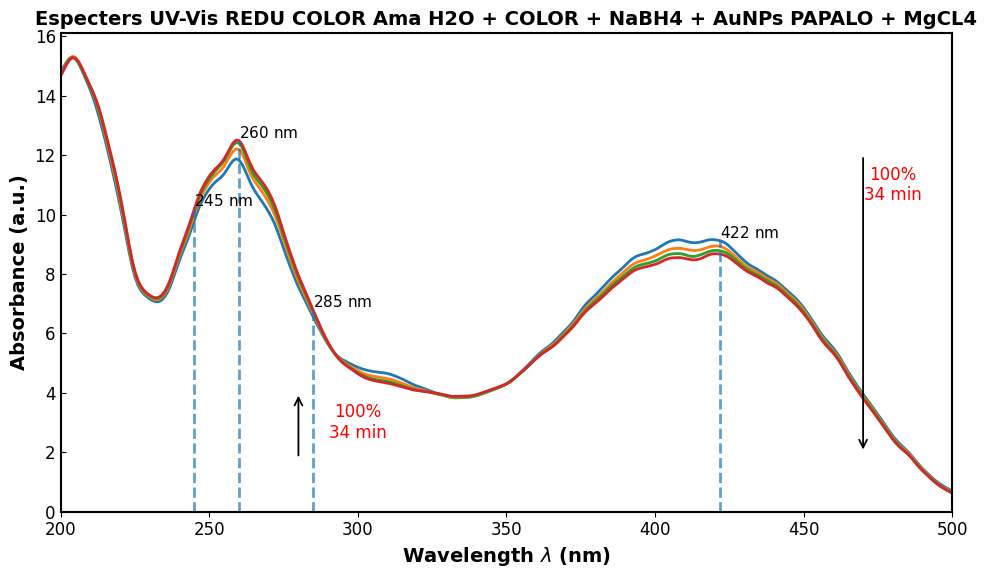


TABLE 1 (Abs a 410 nm)
   X   Abs_410
0  0  9.115714
1  2  8.844143
2  4  8.653274
3  6  8.528641


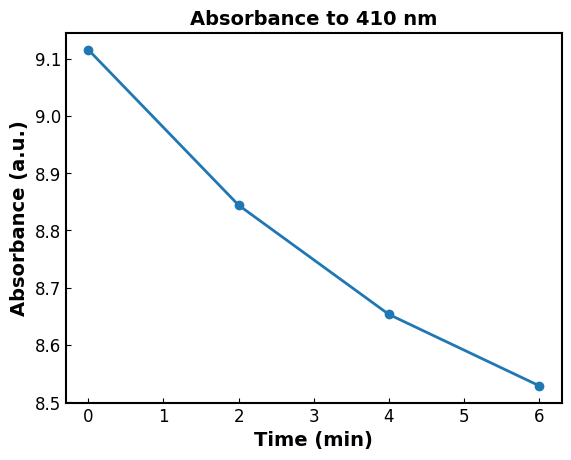


TABLE 2 (Normalize)
   X  Abs_norm
0  0  1.000000
1  2  0.970208
2  4  0.949270
3  6  0.935598


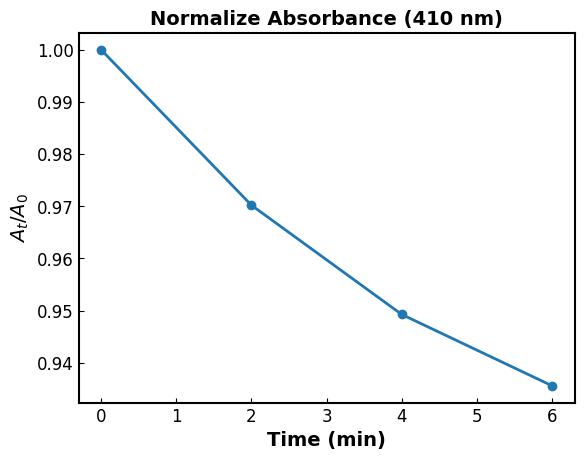


TABLE 3 (Log)
   X  ln(Abs_norm)
0  0      0.000000
1  2     -0.030244
2  4     -0.052062
3  6     -0.066570


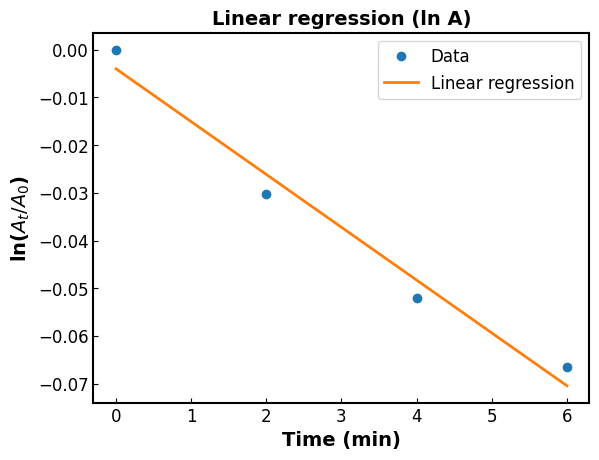


Slope = -0.011076
Standard error of the slope = 0.001245
IC 95% slope = [-0.016432, -0.005721]

Intercept = -0.003990
Standard error of intercept = 0.004657
IC 95% intercept = [-0.024029, 0.016049]

R² = 0.975366

Constant speed k = 0.011076
IC 95% k = [0.005721, 0.016432]

RESIDUES TABLE:
   Time  Experimental value  Adjusted value   Residue
0     0            0.000000       -0.003990  0.003990
1     2           -0.030244       -0.026143 -0.004102
2     4           -0.052062       -0.048295 -0.003767
3     6           -0.066570       -0.070448  0.003878


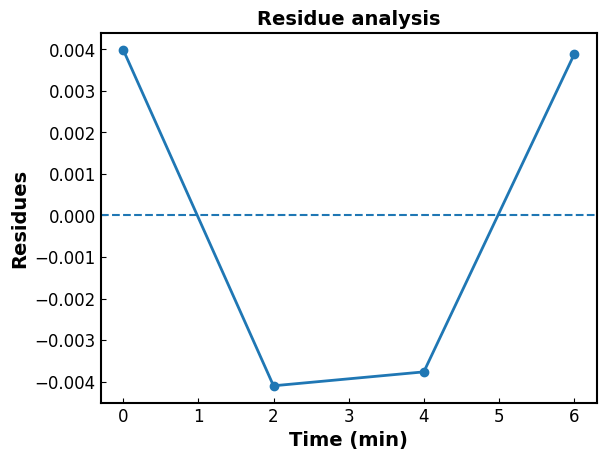

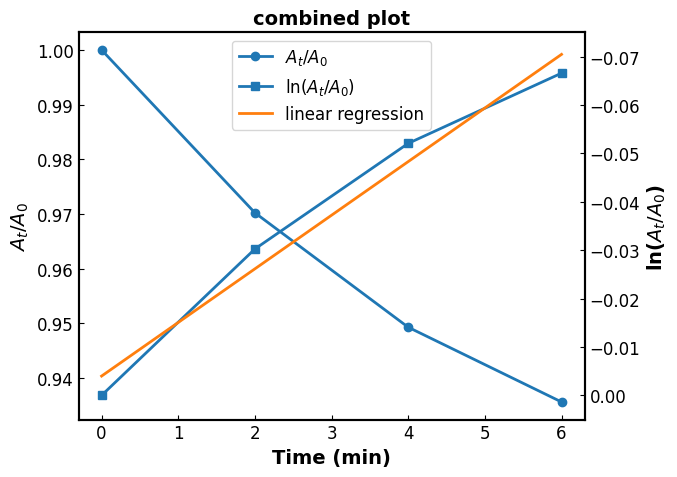


Efficiency = 6.44%

k′ = 11245.015288

Qt = 387.408645 g/g

ΔG‡ = 94.3311 kJ/mol
Standard error ΔG‡ = ±0.2786 kJ/mol
IC95% ΔG‡ = [93.1326, 95.5297]

TON = 12.615042
TOF = 2.102507 min^-1


In [24]:
##########################################################################
# MAIN EXECUTION
##########################################################################

config = ConfiguracionExperimento()

LectorUVVis.verificar_archivos(config.archivos)

grafica = GraficaUVVis(config)

grafica.graficar_espectros()

config = ConfiguracionExperimento()

analisis = AnalisisUVVis(config)

analisis.extraer_absorbancia()

analisis.graficar_absorbancia()

analisis.normalizar()

analisis.graficar_normalizado()

analisis.regresion_lineal()

analisis.grafica_combinada()

analisis.calcular_eficiencia()

analisis.calcular_parametros_cataliticos()
